In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total images in train: 1000


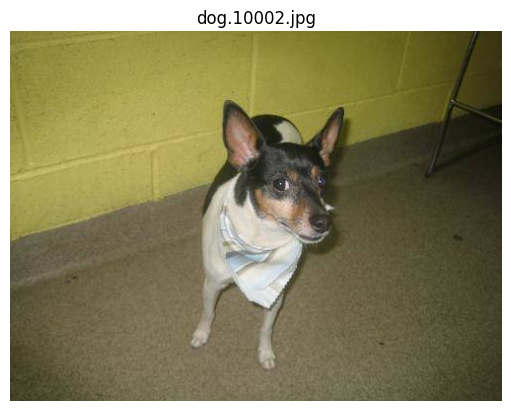

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from PIL import Image
import matplotlib.pyplot as plt
import os

train_path = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/train'

# List all images
all_images = [f for f in os.listdir(train_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f"Total images in train: {len(all_images)}")

# Show 1 image
img = Image.open(os.path.join(train_path, all_images[0]))
plt.imshow(img)
plt.title(all_images[0])
plt.axis('off')
plt.show()

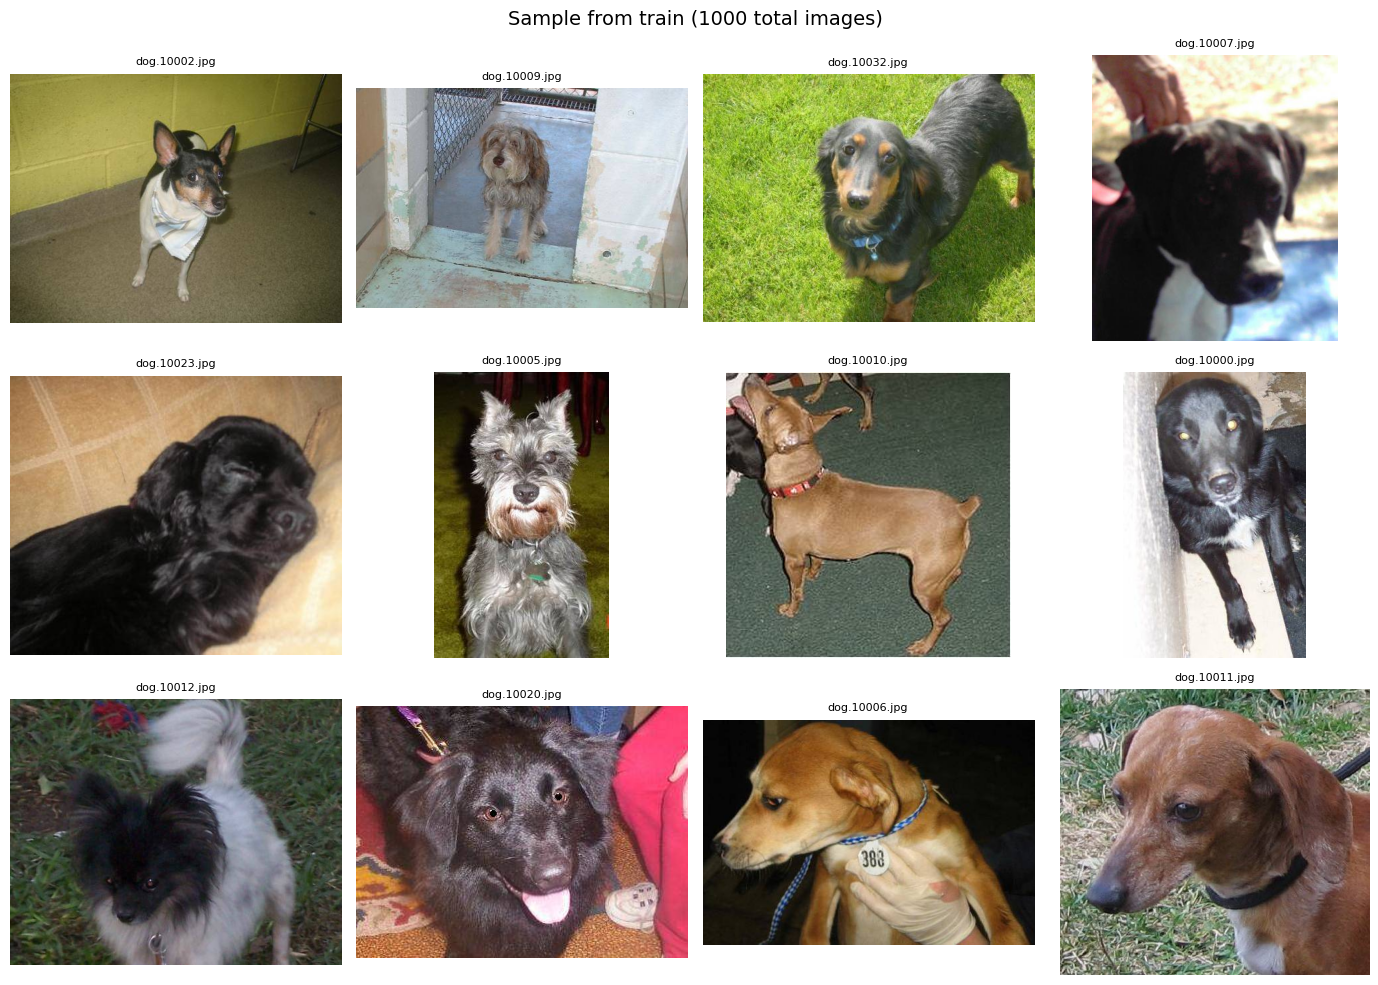

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

train_path = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/train'

all_images = [f for f in os.listdir(train_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Show a grid of 12 images
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i in range(12):
    img = Image.open(os.path.join(train_path, all_images[i]))
    axes[i].imshow(img)
    axes[i].set_title(all_images[i][:15], fontsize=8)  # show filename
    axes[i].axis('off')

plt.suptitle(f'Sample from train ({len(all_images)} total images)', fontsize=14)
plt.tight_layout()
plt.show()

Sorted — Cats: 455 | Dogs: 545
Found 455 images belonging to 1 classes.
cats done — 51 images saved to Drive
Found 545 images belonging to 1 classes.
dogs done — 51 images saved to Drive

All done! Structure in Drive:
  augmented/cats/ → 51 images
  augmented/dogs/ → 51 images


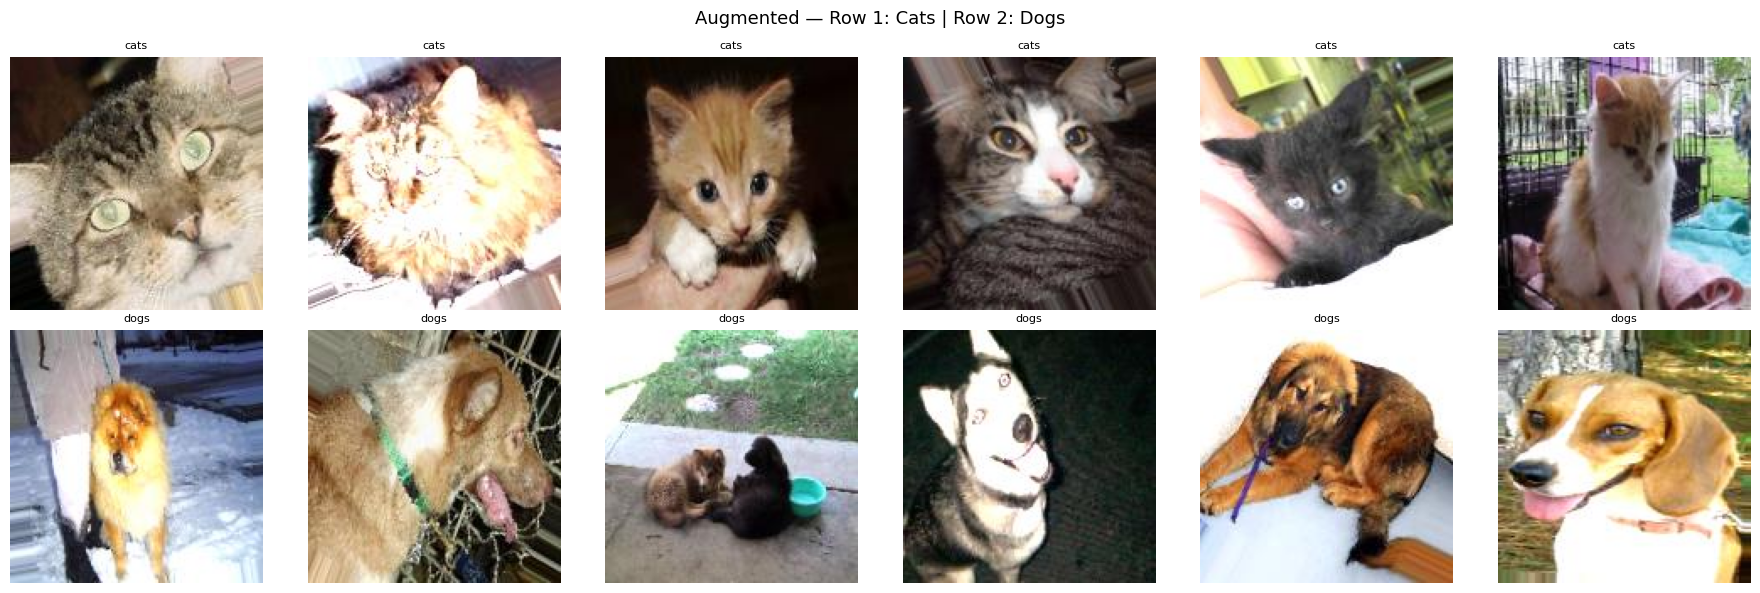

In [5]:

import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from PIL import Image

# ── Paths ─────────────────────────────────────────────────────────
train_path = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/train'
aug_base   = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/augmented'

# ── Step 1: Sort into subfolders ──────────────────────────────────
cats_dir = os.path.join(train_path, 'cats')
dogs_dir = os.path.join(train_path, 'dogs')
os.makedirs(cats_dir, exist_ok=True)
os.makedirs(dogs_dir, exist_ok=True)

for fname in os.listdir(train_path):
    if fname.endswith(('.jpg', '.jpeg', '.png')):
        if fname.lower().startswith('cat'):
            shutil.copy(os.path.join(train_path, fname), os.path.join(cats_dir, fname))
        elif fname.lower().startswith('dog'):
            shutil.copy(os.path.join(train_path, fname), os.path.join(dogs_dir, fname))

print(f"Sorted — Cats: {len(os.listdir(cats_dir))} | Dogs: {len(os.listdir(dogs_dir))}")

# ── Step 2: Define augmentations ──────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=30,
    brightness_range=[0.4, 1.8],
    zoom_range=0.15,
    fill_mode='nearest'
)

# ── Step 3: Augment cats and dogs separately into Drive ───────────
os.makedirs(f'{aug_base}/cats', exist_ok=True)
os.makedirs(f'{aug_base}/dogs', exist_ok=True)

for label, folder in [('cats', cats_dir), ('dogs', dogs_dir)]:
    gen = datagen.flow_from_directory(
        train_path,
        classes=[label],
        target_size=(150, 150),
        batch_size=1,
        save_to_dir=f'{aug_base}/{label}',
        save_prefix=f'aug_{label}',
        save_format='jpeg'
    )

    # generate 50 augmented images per class
    for i, batch in enumerate(gen):
        if i >= 50:
            break

    print(f"{label} done — {len(os.listdir(f'{aug_base}/{label}'))} images saved to Drive")

print("\nAll done! Structure in Drive:")
print(f"  augmented/cats/ → {len(os.listdir(f'{aug_base}/cats'))} images")
print(f"  augmented/dogs/ → {len(os.listdir(f'{aug_base}/dogs'))} images")

# ── Step 4: Preview ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for row, label in enumerate(['cats', 'dogs']):
    images = os.listdir(f'{aug_base}/{label}')[:6]
    for col, fname in enumerate(images):
        img = Image.open(f'{aug_base}/{label}/{fname}')
        axes[row][col].imshow(img)
        axes[row][col].set_title(label, fontsize=8)
        axes[row][col].axis('off')

plt.suptitle('Augmented — Row 1: Cats | Row 2: Dogs', fontsize=13)
plt.tight_layout()
plt.show()

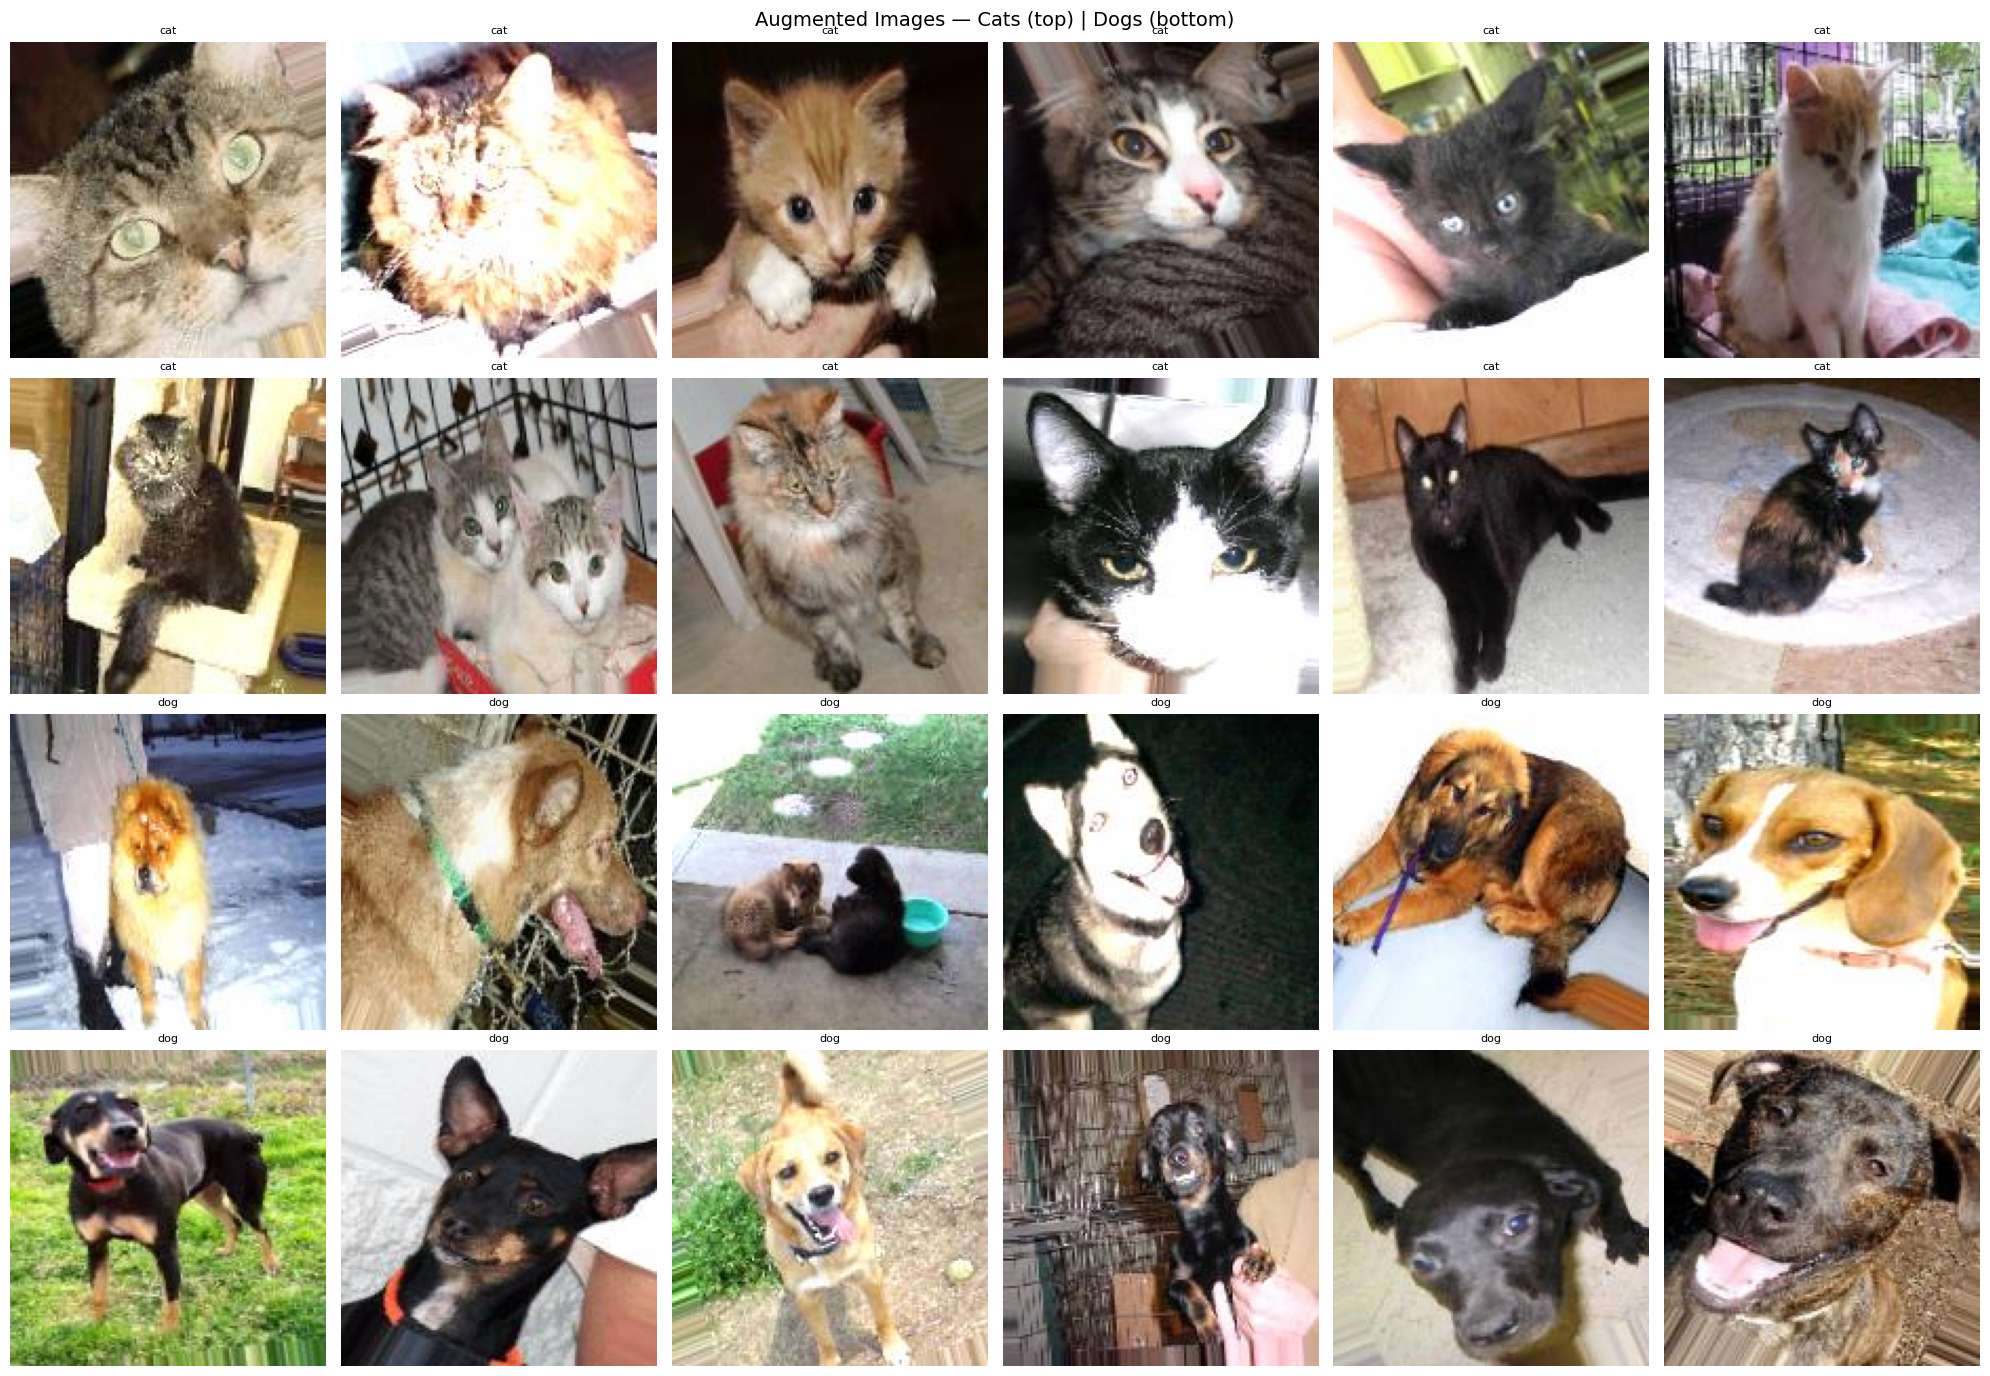

In [6]:

aug_base = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/augmented'

# ── Show 12 augmented cats ────────────────────────────────────────
cat_images = os.listdir(f'{aug_base}/cats')[:12]
dog_images = os.listdir(f'{aug_base}/dogs')[:12]

fig, axes = plt.subplots(4, 6, figsize=(20, 14))

# Row 1 & 2 — Cats
for i, fname in enumerate(cat_images):
    img = Image.open(f'{aug_base}/cats/{fname}')
    axes[i//6][i%6].imshow(img)
    axes[i//6][i%6].set_title('cat', fontsize=8)
    axes[i//6][i%6].axis('off')

# Row 3 & 4 — Dogs
for i, fname in enumerate(dog_images):
    img = Image.open(f'{aug_base}/dogs/{fname}')
    axes[2 + i//6][i%6].imshow(img)
    axes[2 + i//6][i%6].set_title('dog', fontsize=8)
    axes[2 + i//6][i%6].axis('off')

plt.suptitle('Augmented Images — Cats (top) | Dogs (bottom)', fontsize=14)
plt.tight_layout()
plt.show()

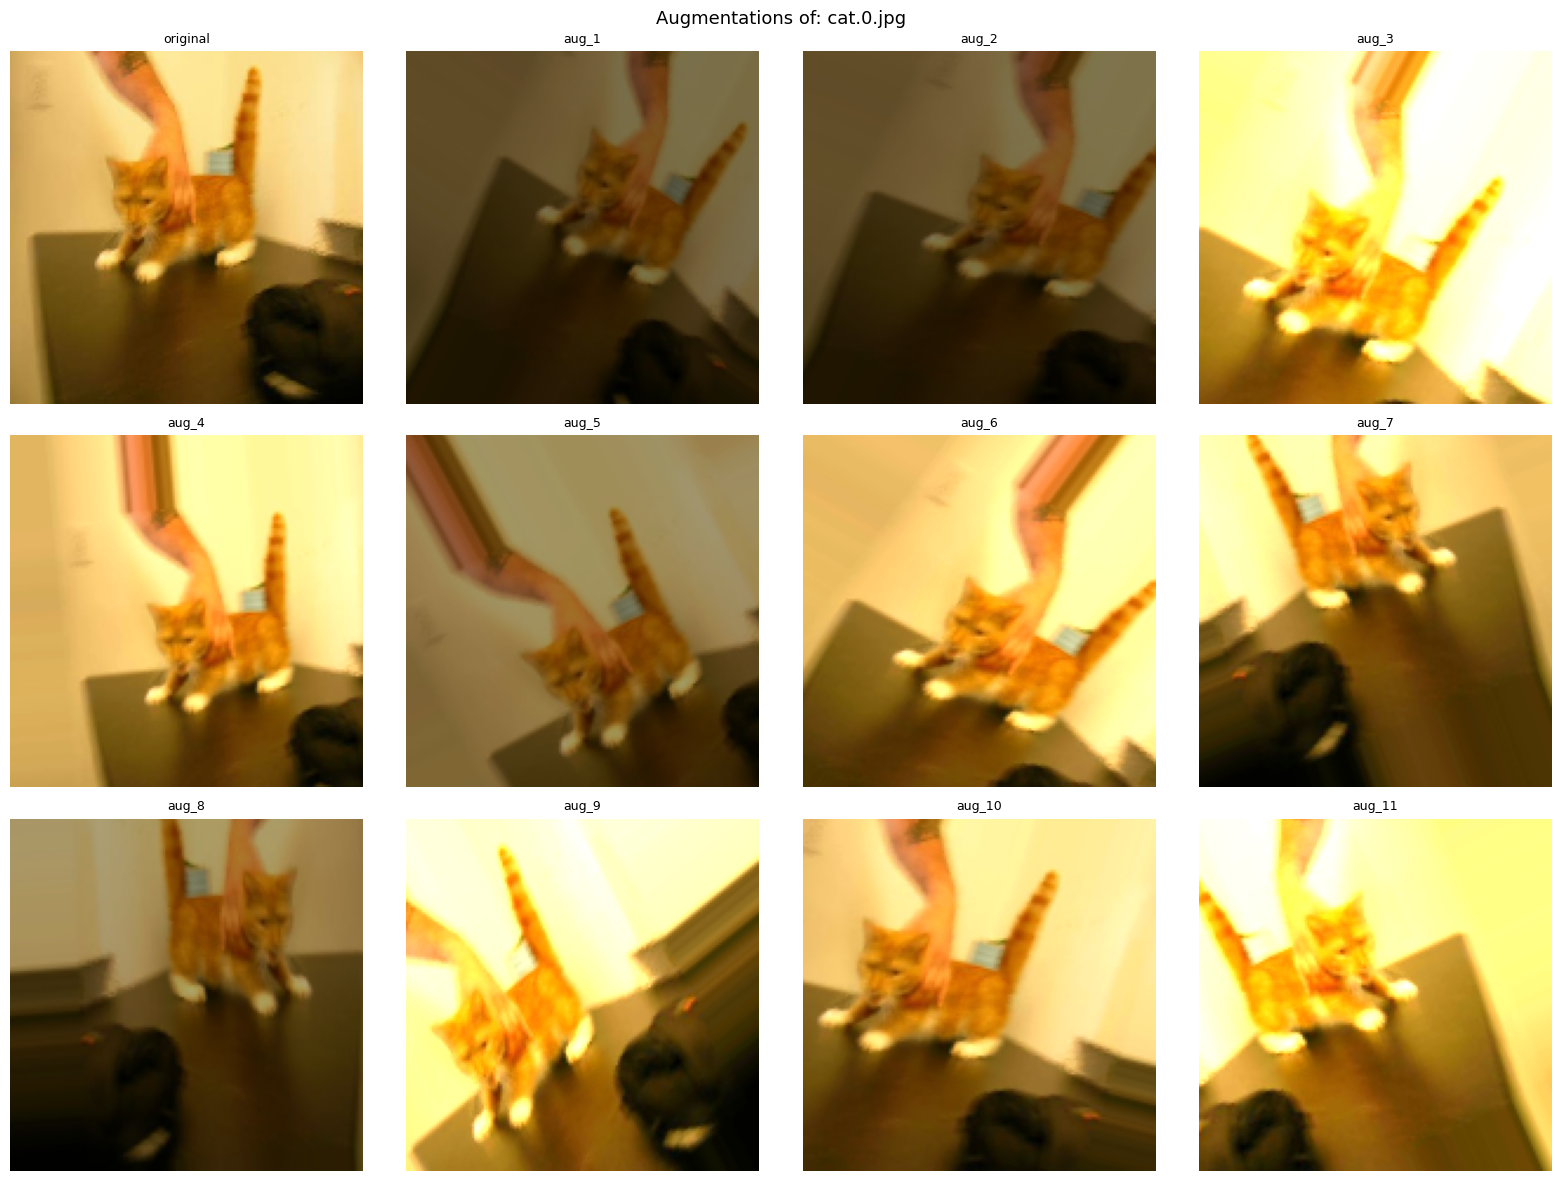

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Load a single cat image ───────────────────────────────────────
cat_path = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/train/cats'
single_image = os.listdir(cat_path)[0]

img = load_img(f'{cat_path}/{single_image}', target_size=(150, 150))
img_array = img_to_array(img).reshape((1, 150, 150, 3))

# ── Define augmentations (no vertical flip) ───────────────────────
datagen = ImageDataGenerator(
    rotation_range=40,
    horizontal_flip=True,       # ✅ horizontal flip
    brightness_range=[0.4, 1.8],
    zoom_range=0.15,
    width_shift_range=0.2,      # shift image left/right
    height_shift_range=0.2,     # shift image up/down
    shear_range=0.2,            # slant the image
    fill_mode='nearest',
    vertical_flip=False         # ❌ no vertical flip
)

# ── Generate and display 12 augmentations ────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# original
axes[0].imshow(img)
axes[0].set_title('original', fontsize=9)
axes[0].axis('off')

# 11 augmented versions
for i, batch in enumerate(datagen.flow(img_array, batch_size=1)):
    axes[i+1].imshow(batch[0].astype('uint8'))
    axes[i+1].set_title(f'aug_{i+1}', fontsize=9)
    axes[i+1].axis('off')
    if i >= 10:
        break

plt.suptitle(f'Augmentations of: {single_image}', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path  = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/train'
final_train = '/content/drive/MyDrive/ML_DATASETS/cats_dogs_light/final_train'

# ── Step 1: Copy originals into final_train ───────────────────────
for label in ['cats', 'dogs']:
    out_dir = f'{final_train}/{label}'
    os.makedirs(out_dir, exist_ok=True)
    src = f'{train_path}/{label}'
    for fname in os.listdir(src):
        shutil.copy(f'{src}/{fname}', f'{out_dir}/{fname}')
    print(f"Originals copied — {label}: {len(os.listdir(out_dir))} images")

# ── Step 2: Define augmentations ─────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=40,
    horizontal_flip=True,
    brightness_range=[0.4, 1.8],
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    fill_mode='nearest',
    vertical_flip=False
)

# ── Step 3: Generate 5000 augmented per class into final_train ────
NUM_AUGMENTED = 5000

for label in ['cats', 'dogs']:
    existing = len(os.listdir(f'{final_train}/{label}'))
    needed   = NUM_AUGMENTED - existing

    if needed <= 0:
        print(f"{label} already has {existing} images, skipping!")
        continue

    gen = datagen.flow_from_directory(
        train_path,
        classes=[label],
        target_size=(150, 150),
        batch_size=1,
        save_to_dir=f'{final_train}/{label}',
        save_prefix=f'aug_{label}',
        save_format='jpeg'
    )

    for i, batch in enumerate(gen):
        if i >= needed:
            break
        if i % 500 == 0:
            print(f"{label}: {existing + i}/{NUM_AUGMENTED + existing} done...")

    total = len(os.listdir(f'{final_train}/{label}'))
    print(f"{label} done! Total: {total} images")

# ── Final summary ─────────────────────────────────────────────────
print("\n✅ All done!")
print(f"final_train/cats → {len(os.listdir(f'{final_train}/cats'))} images")
print(f"final_train/dogs → {len(os.listdir(f'{final_train}/dogs'))} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Originals copied — cats: 455 images
Originals copied — dogs: 545 images
Found 455 images belonging to 1 classes.
cats: 455/5455 done...
cats: 955/5455 done...
cats: 1455/5455 done...
cats: 1955/5455 done...
cats: 2455/5455 done...
cats: 2955/5455 done...
cats: 3455/5455 done...
cats: 3955/5455 done...
cats: 4455/5455 done...
cats: 4955/5455 done...
cats done! Total: 5001 images
Found 545 images belonging to 1 classes.
dogs: 545/5545 done...
dogs: 1045/5545 done...
dogs: 1545/5545 done...
dogs: 2045/5545 done...
dogs: 2545/5545 done...
dogs: 3045/5545 done...
dogs: 3545/5545 done...
dogs: 4045/5545 done...
dogs: 4545/5545 done...
dogs done! Total: 5001 images

✅ All done!
final_train/cats → 5001 images
final_train/dogs → 5001 images
